<a href="https://colab.research.google.com/github/Mario-Cattaneo/SemesterProject/blob/main/Eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Cell 1: Imports and Device Setup
import copy
import math
from dataclasses import dataclass, field
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device}")

Executing on device: cuda


In [10]:
# Cell 2: Hierarchical Configuration via Dataclasses


@dataclass
class ChannelConfig:
    capacity_mbps: float  # C_{i,j} in Mbps
    prop_delay_ms: float  # t_{i,j}^prop in ms
    bit_width: int = 8  # b bits


@dataclass
class NodeConfig:
    device_name: str
    exec_time_ms: float  # t_i^exec in ms


@dataclass
class ALMConfig:
    t_max: float  # Latency constraint SLA
    lambda1_init: float = 0.0  # lambda_1^(0)
    lambda2_init: float = 0.005  # lambda_2^(0): scaled to match cross-entropy
    rho: float = 1.5  # Penalty expansion factor
    tau_viol: float = 0.25  # Tolerance reduction factor
    e_step: int = 2  # Outer-loop update period (epochs)


@dataclass
class GateConfig:
    alpha: float = (
        10.0  # Smooth-max temperature in LogSumExp (held strictly constant)
    )
    beta_init: float = 1.5  # Initial gate temperature beta_0
    beta_min: float = 0.05  # Minimum temperature beta_min
    decay_rate: float = 0.90  # Annealing factor r_beta
    gamma: float = -0.1  # Hard concrete stretch parameter
    zeta: float = 1.1  # Hard concrete stretch parameter
    s_init: float = 1.5  # Initial gate logit


@dataclass
class ExperimentConfig:
    experiment_name: str = "TBN_Fork_Join"
    batch_size: int = 128
    epochs: int = 8
    lr_s: float = 0.02
    lr_c: float = 0.01
    nodes: Dict[int, NodeConfig] = field(default_factory=dict)
    edges: Dict[Tuple[int, int], ChannelConfig] = field(default_factory=dict)
    alm: ALMConfig = field(default_factory=lambda: ALMConfig(t_max=25.0))
    gate: GateConfig = field(default_factory=GateConfig)


print("Cell 2: Pure paper configuration ready.")

Cell 2: Pure paper configuration ready.


In [11]:
# Cell 3: Hard Concrete Gating and Imputation Bottleneck Module


class EdgeBottleneck(nn.Module):
    """Placed on channel (i,j).

    Learns which features to transmit (s) and what continuous values to impute
    (c).
    """

    def __init__(
        self,
        feature_shape: Tuple[int, ...],
        channel_cfg: ChannelConfig,
        gate_cfg: GateConfig,
    ):
        super().__init__()
        self.feature_shape = (
            feature_shape  # e.g., (Channels, Height, Width) or (Channels,)
        )
        self.channel_cfg = channel_cfg
        self.gate_cfg = gate_cfg

        # Number of gating units (one per channel for CNN feature maps)
        num_gates = feature_shape[0]
        self.elements_per_gate = int(np.prod(feature_shape[1:]))

        # Learnable parameters: gate logits (s) and continuous imputations (c)
        self.s = nn.Parameter(torch.full((num_gates,), gate_cfg.s_init))
        self.c = nn.Parameter(torch.zeros(feature_shape))

    def get_transmission_prob(self, beta: float) -> torch.Tensor:
        """Evaluates p(m > 0) in closed form."""
        offset = beta * math.log(-self.gate_cfg.gamma / self.gate_cfg.zeta)
        return torch.sigmoid(self.s - offset)

    def expected_transmission_time_ms(self, beta: float) -> torch.Tensor:
        """Analytic, differentiable expected channel transmission latency."""
        probs = self.get_transmission_prob(beta)
        expected_active_gates = torch.sum(probs)
        total_bits = (
            expected_active_gates
            * self.elements_per_gate
            * self.channel_cfg.bit_width
        )
        # Latency = (bits / (Mbps * 1e6)) * 1000 ms
        trans_time_ms = (
            total_bits / (self.channel_cfg.capacity_mbps * 1e6)
        ) * 1000.0
        return trans_time_ms

    def forward(
        self, z: torch.Tensor, beta: float, deterministic: bool = False
    ) -> Tuple[torch.Tensor, float]:
        """Forward pass: applies either stochastic relaxation or deterministic

        pruning.
        """
        view_shape = [1, -1] + [1] * (len(self.feature_shape) - 1)

        if not deterministic:
            # Training: Hard Concrete reparameterization
            eps = torch.rand_like(self.s).clamp(1e-6, 1.0 - 1e-6)
            logits_eps = torch.log(eps) - torch.log(1.0 - eps)
            m_tilde = torch.sigmoid((logits_eps + self.s) / beta)
            m_bar = (
                m_tilde * (self.gate_cfg.zeta - self.gate_cfg.gamma)
                + self.gate_cfg.gamma
            )
            m = torch.clamp(m_bar, 0.0, 1.0).view(view_shape)

            # Imputed representation u = z * m + (1 - m) * c
            c_expanded = self.c.unsqueeze(0)
            u = z * m + (1.0 - m) * c_expanded
            active_fraction = float(m.mean().item())
            return u, active_fraction
        else:
            # Test-time / Evaluation: Deterministic Thresholding
            threshold = beta * math.log(
                -self.gate_cfg.gamma / self.gate_cfg.zeta
            )
            hard_mask = (self.s >= threshold).float().view(view_shape)

            c_expanded = self.c.unsqueeze(0)
            u = z * hard_mask + (1.0 - hard_mask) * c_expanded
            active_fraction = float(hard_mask.mean().item())
            return u, active_fraction


print("EdgeBottleneck module ready.")

EdgeBottleneck module ready.


In [12]:
# Cell 4: Differentiable DAG Critical-Path Recursion Engine


class DAGTimingEngine:
    """Computes critical-path latency through the DAG using stable LogSumExp."""

    def __init__(
        self,
        nodes: Dict[int, NodeConfig],
        edges: Dict[Tuple[int, int], ChannelConfig],
    ):
        self.nodes = nodes
        self.edges = edges

        # Build adjacency maps
        self.parents: Dict[int, List[int]] = {i: [] for i in nodes}
        self.children: Dict[int, List[int]] = {i: [] for i in nodes}
        for u, v in edges.keys():
            self.parents[v].append(u)
            self.children[u].append(v)

        # Topological ordering
        self.topo_order = self._get_topological_sort()
        self.terminal_node = self.topo_order[-1]

    def _get_topological_sort(self) -> List[int]:
        in_degree = {i: len(self.parents[i]) for i in self.nodes}
        queue = [i for i in self.nodes if in_degree[i] == 0]
        order = []
        while queue:
            curr = queue.pop(0)
            order.append(curr)
            for nxt in self.children[curr]:
                in_degree[nxt] -= 1
                if in_degree[nxt] == 0:
                    queue.append(nxt)
        return order

    def compute_relaxed_latency(
        self,
        bottlenecks: Dict[Tuple[int, int], EdgeBottleneck],
        beta: float,
        alpha: float,
    ) -> torch.Tensor:
        """Differentiable forward pass for training loss (tilde{t})."""
        t_tilde: Dict[int, torch.Tensor] = {}

        for j in self.topo_order:
            t_exec = torch.tensor(
                self.nodes[j].exec_time_ms, device=bottlenecks[(0, 1)].s.device
            )

            if len(self.parents[j]) == 0:
                t_tilde[j] = t_exec
            else:
                branch_arrivals = []
                for i in self.parents[j]:
                    t_trans = bottlenecks[(i, j)].expected_transmission_time_ms(
                        beta
                    )
                    t_prop = torch.tensor(
                        self.edges[(i, j)].prop_delay_ms, device=t_trans.device
                    )
                    z_ij = t_tilde[i] + t_prop + t_trans
                    branch_arrivals.append(z_ij)

                stacked_z = torch.stack(branch_arrivals)

                # Numerically stable LogSumExp identity: z_max + (1/alpha)*log(sum(exp(alpha*(z - z_max))))
                z_max = torch.max(stacked_z).detach()
                lse = z_max + (1.0 / alpha) * torch.log(
                    torch.sum(torch.exp(alpha * (stacked_z - z_max)))
                )
                t_tilde[j] = t_exec + lse

        return t_tilde[self.terminal_node]

    def compute_physical_latency(
        self,
        bottlenecks: Dict[Tuple[int, int], EdgeBottleneck],
        beta: float,
        deterministic: bool = True,
    ) -> float:
        """Calculates exact physical runtime on hardware (hard max)."""
        t_physical: Dict[int, float] = {}

        for j in self.topo_order:
            t_exec = self.nodes[j].exec_time_ms

            if len(self.parents[j]) == 0:
                t_physical[j] = t_exec
            else:
                branch_delays = []
                for i in self.parents[j]:
                    bneck = bottlenecks[(i, j)]
                    if deterministic:
                        thresh = beta * math.log(
                            -bneck.gate_cfg.gamma / bneck.gate_cfg.zeta
                        )
                        active_count = (bneck.s >= thresh).sum().item()
                    else:
                        active_count = (
                            bneck.get_transmission_prob(beta).sum().item()
                        )

                    total_bits = (
                        active_count
                        * bneck.elements_per_gate
                        * bneck.channel_cfg.bit_width
                    )
                    t_trans = (
                        total_bits / (self.edges[(i, j)].capacity_mbps * 1e6)
                    ) * 1000.0
                    t_prop = self.edges[(i, j)].prop_delay_ms
                    branch_delays.append(t_physical[i] + t_prop + t_trans)

                t_physical[j] = t_exec + max(branch_delays)

        return t_physical[self.terminal_node]


print("TimingEngine ready.")

TimingEngine ready.


In [13]:
# Cell 5: Collaborative ResNet DAG with Residual Micro-Splits


class ResBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return F.relu(x + self.conv(x))


class CollaborativeResNetDAG(nn.Module):

    def __init__(self, cfg: ExperimentConfig):
        super().__init__()
        self.cfg = cfg

        # Device 0: Input Stem + ResBlock (Outputs 64 channels)
        self.node0_split = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResBlock(64),
        )

        # Device 1: Parallel Worker A (Processes 32 channels -> outputs 64)
        self.node1_split = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResBlock(64),
        )

        # Device 2: Parallel Worker B (Processes 32 channels -> outputs 64)
        self.node2_split = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResBlock(64),
        )

        # Device 3: Concatenation (64+64 = 128 channels) + ResBlock + Classifier
        self.node3_split = nn.Sequential(
            ResBlock(128),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 10),
        )

        # EdgeBottlenecks for directed channels
        self.bottlenecks = nn.ModuleDict()
        self.bottlenecks["0->1"] = EdgeBottleneck(
            (32, 32, 32), cfg.edges[(0, 1)], cfg.gate
        )
        self.bottlenecks["0->2"] = EdgeBottleneck(
            (32, 32, 32), cfg.edges[(0, 2)], cfg.gate
        )
        self.bottlenecks["1->3"] = EdgeBottleneck(
            (64, 16, 16), cfg.edges[(1, 3)], cfg.gate
        )
        self.bottlenecks["2->3"] = EdgeBottleneck(
            (64, 16, 16), cfg.edges[(2, 3)], cfg.gate
        )

    def get_bottleneck_map(self) -> Dict[Tuple[int, int], EdgeBottleneck]:
        return {
            (0, 1): self.bottlenecks["0->1"],
            (0, 2): self.bottlenecks["0->2"],
            (1, 3): self.bottlenecks["1->3"],
            (2, 3): self.bottlenecks["2->3"],
        }

    def forward(
        self, x: torch.Tensor, beta: float, deterministic: bool = False
    ) -> torch.Tensor:
        z0 = self.node0_split(x)
        z0_A, z0_B = torch.split(z0, 32, dim=1)

        u01, _ = self.bottlenecks["0->1"](
            z0_A, beta, deterministic=deterministic
        )
        u02, _ = self.bottlenecks["0->2"](
            z0_B, beta, deterministic=deterministic
        )

        z1 = self.node1_split(u01)
        z2 = self.node2_split(u02)

        u13, _ = self.bottlenecks["1->3"](
            z1, beta, deterministic=deterministic
        )
        u23, _ = self.bottlenecks["2->3"](
            z2, beta, deterministic=deterministic
        )

        z_concat = torch.cat([u13, u23], dim=1)
        return self.node3_split(z_concat)


print("Cell 5: Upgraded residual architecture ready.")

Cell 5: Upgraded residual architecture ready.


In [14]:
# Cell 6: ALMTrainer Strictly Following Algorithm 1 from the Paper


class ALMTrainer:

    def __init__(
        self,
        model: CollaborativeResNetDAG,
        timing_engine: DAGTimingEngine,
        cfg: ExperimentConfig,
    ):
        self.model = model.to(device)
        self.timing_engine = timing_engine
        self.cfg = cfg

        # Dual variables from paper
        self.lambda1 = cfg.alm.lambda1_init
        self.lambda2 = cfg.alm.lambda2_init
        self.prev_violation = float("inf")

        # Isolate parameters: s and c are optimized, backbone is frozen
        s_params = [
            bneck.s for bneck in self.model.get_bottleneck_map().values()
        ]
        c_params = [
            bneck.c for bneck in self.model.get_bottleneck_map().values()
        ]

        self.optimizer = optim.Adam(
            [
                {"params": s_params, "lr": cfg.lr_s},
                {"params": c_params, "lr": cfg.lr_c},
            ]
        )
        self.criterion = nn.CrossEntropyLoss()

    def train_epoch(self, dataloader, epoch: int) -> Dict[str, float]:
        self.model.train()

        # Temperature annealing strictly per paper equation
        beta = max(
            self.cfg.gate.beta_min, self.cfg.gate.beta_init * (self.cfg.gate.decay_rate**epoch)
        )

        total_loss, correct, total = 0.0, 0, 0
        bneck_map = self.model.get_bottleneck_map()

        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            self.optimizer.zero_grad()

            # Task Loss (Relevance Term)
            y_hat = self.model(x, beta=beta, deterministic=False)
            task_loss = self.criterion(y_hat, y)

            # Differentiable critical path latency (tilde{t}) via LogSumExp
            tilde_t = self.timing_engine.compute_relaxed_latency(
                bneck_map, beta=beta, alpha=self.cfg.gate.alpha
            )

            # Latency Penalty strictly per paper equation: lambda1 * delta + lambda2 * delta^2
            delta = torch.clamp(tilde_t - self.cfg.alm.t_max, min=0.0)
            latency_penalty = self.lambda1 * delta + self.lambda2 * (delta**2)

            # Combined Primal Loss
            loss = task_loss + latency_penalty
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * x.size(0)
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += x.size(0)

        # Outer ALM Step strictly per paper equations (26) and (27)
        if (epoch + 1) % self.cfg.alm.e_step == 0:
            with torch.no_grad():
                current_tilde_t = (
                    self.timing_engine.compute_relaxed_latency(
                        bneck_map, beta=beta, alpha=self.cfg.gate.alpha
                    ).item()
                )
                curr_violation = max(0.0, current_tilde_t - self.cfg.alm.t_max)

                # Linear multiplier update: lambda1 <- max(0, lambda1 + 2*lambda2*delta)
                self.lambda1 = max(
                    0.0, self.lambda1 + 2.0 * self.lambda2 * curr_violation
                )

                # Conditional quadratic penalty update
                if curr_violation > self.cfg.alm.tau_viol * self.prev_violation:
                    self.lambda2 *= self.cfg.alm.rho

                self.prev_violation = curr_violation
                print(
                    f" [ALM Outer Step @ Epoch {epoch+1:02d}] Latency: {current_tilde_t:.2f} ms "
                    f"(Target SLA: {self.cfg.alm.t_max:.1f} ms) | lambda1: {self.lambda1:.4f} | lambda2: {self.lambda2:.5f}"
                )

        return {
            "loss": total_loss / total,
            "acc": 100.0 * correct / total,
            "beta": beta,
        }

    @torch.no_grad()
    def evaluate(self, dataloader) -> Tuple[float, float, Dict[str, float]]:
        self.model.eval()
        correct, total = 0, 0
        beta_eval = self.cfg.gate.beta_min
        bneck_map = self.model.get_bottleneck_map()

        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            y_hat = self.model(x, beta=beta_eval, deterministic=True)
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += x.size(0)

        accuracy = 100.0 * correct / total
        physical_latency = self.timing_engine.compute_physical_latency(
            bneck_map, beta=beta_eval, deterministic=True
        )

        retained_ratios = {}
        for edge_key, bneck in bneck_map.items():
            thresh = beta_eval * math.log(
                -bneck.gate_cfg.gamma / bneck.gate_cfg.zeta
            )
            ratio = (bneck.s >= thresh).float().mean().item()
            retained_ratios[f"{edge_key[0]}->{edge_key[1]}"] = ratio * 100.0

        return accuracy, physical_latency, retained_ratios


print("Cell 6: Strict Algorithm 1 ALMTrainer compiled.")

Cell 6: Strict Algorithm 1 ALMTrainer compiled.


Loaded full dataset: 50000 train images, 10000 test images.
  STEP 1: Pretraining the Collaborative Backbone (Uncompressed)
Pretrain Epoch 05/20 | Train Acc: 76.56%
Pretrain Epoch 10/20 | Train Acc: 86.35%
Pretrain Epoch 15/20 | Train Acc: 91.19%
Pretrain Epoch 20/20 | Train Acc: 93.65%

>>> UNCOMPRESSED BASELINE: Latency = 49.95 ms | Accuracy = 87.76%

  Optimizing TBN Pruning for SLA = 30.0 ms
Epoch 01/08 | Train Acc: 89.2% | Beta: 1.50
 [ALM Outer Step @ Epoch 02] Latency: 34.37 ms (Target SLA: 30.0 ms) | lambda1: 0.0437 | lambda2: 0.00500
Epoch 02/08 | Train Acc: 89.0% | Beta: 1.35
Epoch 03/08 | Train Acc: 89.5% | Beta: 1.22
 [ALM Outer Step @ Epoch 04] Latency: 33.04 ms (Target SLA: 30.0 ms) | lambda1: 0.0742 | lambda2: 0.00750
Epoch 04/08 | Train Acc: 89.5% | Beta: 1.09
Epoch 05/08 | Train Acc: 89.4% | Beta: 0.98
 [ALM Outer Step @ Epoch 06] Latency: 31.87 ms (Target SLA: 30.0 ms) | lambda1: 0.1022 | lambda2: 0.01125
Epoch 06/08 | Train Acc: 89.3% | Beta: 0.89
Epoch 07/08 | Train

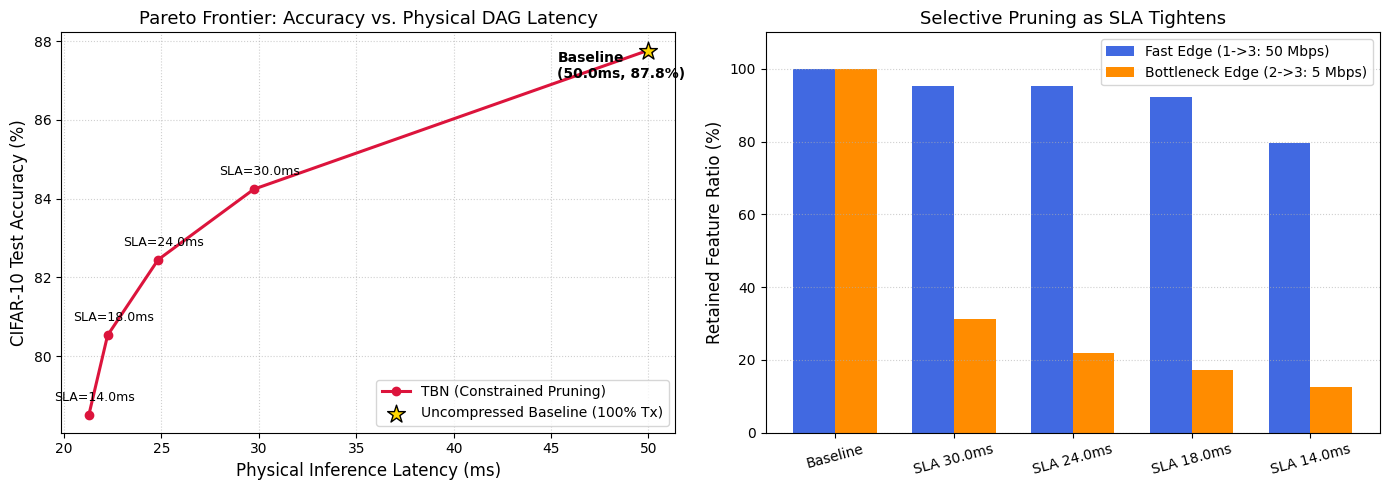

In [15]:
# Cell 7: Full Dataset Training + Baseline Anchor + Stricter SLA Sweeps
import copy
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from google.colab import drive

# 1. Mount Drive & Load FULL CIFAR-10 Dataset (50,000 images)
if not os.path.exists("/content/drive"):
    drive.mount("/content/drive")

cifar_path = "/content/drive/MyDrive/Colab_Datasets/CIFAR10"

transform_train = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
        ),
    ]
)
transform_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
        ),
    ]
)

trainset = torchvision.datasets.CIFAR10(
    root=cifar_path, train=True, download=False, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root=cifar_path, train=False, download=False, transform=transform_test
)

train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    testset, batch_size=256, shuffle=False, num_workers=2
)

print(
    f"Loaded full dataset: {len(trainset)} train images, {len(testset)} test images."
)

# 2. Hardware Topology Setup
nodes = {
    0: NodeConfig(device_name="Ingress_Pi", exec_time_ms=4.0),
    1: NodeConfig(device_name="Worker_A_Jetson", exec_time_ms=3.0),
    2: NodeConfig(device_name="Worker_B_Pi", exec_time_ms=7.0),
    3: NodeConfig(device_name="Terminal_Server", exec_time_ms=2.0),
}
edges = {
    (0, 1): ChannelConfig(capacity_mbps=30.0, prop_delay_ms=1.0),
    (0, 2): ChannelConfig(capacity_mbps=30.0, prop_delay_ms=1.0),
    (1, 3): ChannelConfig(
        capacity_mbps=50.0, prop_delay_ms=1.0
    ),  # Fast link
    (2, 3): ChannelConfig(
        capacity_mbps=5.0, prop_delay_ms=1.0
    ),  # Bottleneck link
}
timing_engine = DAGTimingEngine(nodes, edges)

# ------------------------------------------------------------------------------
# 3. STEP 1: Pretrain the Distributed Backbone (Matches Paper Premise)
# ------------------------------------------------------------------------------
print("===================================================================")
print("  STEP 1: Pretraining the Collaborative Backbone (Uncompressed)")
print("===================================================================")

base_cfg = ExperimentConfig(nodes=nodes, edges=edges)
base_model = CollaborativeResNetDAG(base_cfg).to(device)

# Force gates completely open (100% transmission) during pretraining
for bneck in base_model.get_bottleneck_map().values():
    bneck.s.requires_grad = False
    bneck.c.requires_grad = False
    bneck.s.data.fill_(10.0)

optimizer = torch.optim.AdamW(
    base_model.parameters(), lr=2e-3, weight_decay=5e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    base_model.train()
    correct, total = 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_hat = base_model(x, beta=1.0, deterministic=True)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()
        correct += (y_hat.argmax(dim=1) == y).sum().item()
        total += x.size(0)
    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch == 19:
        print(
            f"Pretrain Epoch {epoch+1:02d}/20 | Train Acc: {100.0 * correct / total:.2f}%"
        )

# Evaluate Uncompressed Baseline
base_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        y_hat = base_model(x, beta=1.0, deterministic=True)
        correct += (y_hat.argmax(dim=1) == y).sum().item()
        total += x.size(0)

base_acc = 100.0 * correct / total
base_latency = timing_engine.compute_physical_latency(
    base_model.get_bottleneck_map(), beta=1.0, deterministic=True
)

print(
    f"\n>>> UNCOMPRESSED BASELINE: Latency = {base_latency:.2f} ms | Accuracy = {base_acc:.2f}%\n"
)
pretrained_weights = copy.deepcopy(base_model.state_dict())

# ------------------------------------------------------------------------------
# 4. STEP 2: Optimize TBN Pruning Across Stricter SLAs
# ------------------------------------------------------------------------------
# Uncompressed baseline is ~32.5 ms. We test progressively tighter SLAs:
t_max_sweep = [30.0, 24.0, 18.0, 14.0]
results = []

for t_target in t_max_sweep:
    print("===================================================================")
    print(f"  Optimizing TBN Pruning for SLA = {t_target:.1f} ms")
    print("===================================================================")

    cfg = ExperimentConfig(
        nodes=nodes, edges=edges, alm=ALMConfig(t_max=t_target), epochs=8
    )

    model = CollaborativeResNetDAG(cfg).to(device)
    model.load_state_dict(copy.deepcopy(pretrained_weights))

    # Freeze pretrained backbone weights: optimize ONLY gates (s) and imputations (c)
    for name, p in model.named_parameters():
        if name.endswith(".s") or name.endswith(".c"):
            p.requires_grad = True
            if name.endswith(".s"):
                p.data.fill_(1.5)  # Initialize slightly positive
            if name.endswith(".c"):
                p.data.zero_()  # Initialize imputations to zero
        else:
            p.requires_grad = False  # Backbone is frozen

    trainer = ALMTrainer(model, timing_engine, cfg)

    for epoch in range(cfg.epochs):
        train_stats = trainer.train_epoch(train_loader, epoch)
        print(
            f"Epoch {epoch+1:02d}/{cfg.epochs:02d} | Train Acc: {train_stats['acc']:.1f}% | Beta: {train_stats['beta']:.2f}"
        )

    test_acc, physical_lat, edge_retention = trainer.evaluate(test_loader)
    print(
        f"\n==> Target SLA: {t_target:.1f} ms | Real Physical Latency: {physical_lat:.2f} ms | Test Acc: {test_acc:.2f}%"
    )
    print(f"    Retention per Edge: {edge_retention}\n")

    results.append(
        {
            "target_t": t_target,
            "real_t": physical_lat,
            "acc": test_acc,
            "retention": edge_retention,
        }
    )

# ------------------------------------------------------------------------------
# 5. STEP 3: Publication Plots (Baseline Anchor vs. TBN Pruning)
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

all_latencies = [base_latency] + [r["real_t"] for r in results]
all_accuracies = [base_acc] + [r["acc"] for r in results]

ax1.plot(
    all_latencies,
    all_accuracies,
    marker="o",
    linewidth=2.2,
    color="crimson",
    label="TBN (Constrained Pruning)",
)
ax1.scatter(
    [base_latency],
    [base_acc],
    color="gold",
    edgecolors="black",
    s=180,
    zorder=5,
    marker="*",
    label="Uncompressed Baseline (100% Tx)",
)
ax1.annotate(
    f"Baseline\n({base_latency:.1f}ms, {base_acc:.1f}%)",
    (base_latency, base_acc),
    textcoords="offset points",
    xytext=(-65, -20),
    fontweight="bold",
)

for r in results:
    ax1.annotate(
        f"SLA={r['target_t']}ms",
        (r["real_t"], r["acc"]),
        textcoords="offset points",
        xytext=(-25, 10),
        fontsize=9,
    )

ax1.set_xlabel("Physical Inference Latency (ms)", fontsize=12)
ax1.set_ylabel("CIFAR-10 Test Accuracy (%)", fontsize=12)
ax1.set_title("Pareto Frontier: Accuracy vs. Physical DAG Latency", fontsize=13)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="lower right")

bar_labels = ["Baseline"] + [f"SLA {r['target_t']}ms" for r in results]
fast_edges = [100.0] + [r["retention"]["1->3"] for r in results]
slow_edges = [100.0] + [r["retention"]["2->3"] for r in results]

x = np.arange(len(bar_labels))
width = 0.35

ax2.bar(
    x - width / 2,
    fast_edges,
    width,
    label="Fast Edge (1->3: 50 Mbps)",
    color="royalblue",
)
ax2.bar(
    x + width / 2,
    slow_edges,
    width,
    label="Bottleneck Edge (2->3: 5 Mbps)",
    color="darkorange",
)

ax2.set_ylabel("Retained Feature Ratio (%)", fontsize=12)
ax2.set_title("Selective Pruning as SLA Tightens", fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(bar_labels, rotation=15)
ax2.set_ylim(0, 110)
ax2.grid(axis="y", linestyle=":", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()